TypeError: Model.cost() got an unexpected keyword argument 'feautures'

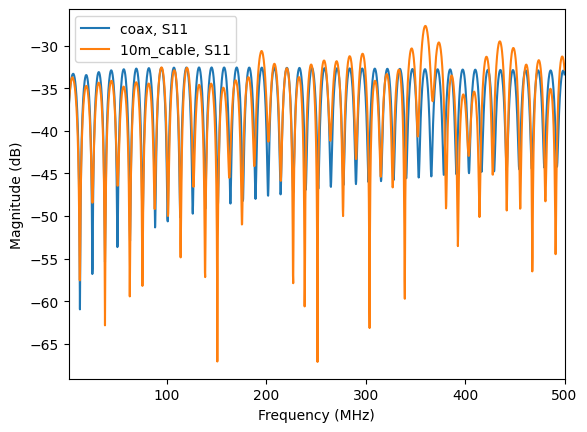

In [7]:
import skrf as rf
import matplotlib.pyplot as plt

from pmrf.models.lines import PhysicalCoaxial
from pmrf.parameter import norm, uniform, fixed
from pmrf.fitting import ScipyFitter
from pmrf._features import FeatureExtractor
from pmrf._modifiers import ModifierChain

params = {
    'din': 0.0011278723699626302,
    'dout': 0.0026965465552947427,
    'length': 10.989558198211467,
    'epr': 1.162099624862902,
    'tand': 5.909156836733568e-05,
    'rho': 1.898225947645188e-08,
}

# Create the model
model = PhysicalCoaxial(name='coax').with_params(**params)
measured = rf.Network('../examples/data/10m_cable.s2p', f_unit='MHz')

model.to_skrf(measured.frequency).plot_s_db(m=0, n=0)
measured.plot_s_db(m=0, n=0)

features = [FeatureExtractor(ports=(0, 0)), FeatureExtractor(ports=(0, 1)), FeatureExtractor(ports=(1, 0)), FeatureExtractor(ports=(1, 1))]
modifiers = ['L2', 'convolve-interleaved', 'L2', 'dB']
# cost_fn = model.make_cost_function(measured, features=features, modifiers=modifiers)

# cost_fn()

print(model.cost(measured=measured, feautures=features, modifiers=modifiers))